<a href="https://colab.research.google.com/github/dhiyasalmas/Thermal-Hydraulic-On-HTGR-Pebble-Bed/blob/main/Termal_Hidrolik_Pebble_Bed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Termal Hidrolik HTR-PM**

### **I. Zona Fluida**

Di dalam zona fluida, perilaku aliran fase tunggal (gas helium) dijelaskan menggunakan :

* **Persamaan kontinuitas massa:**

$$\frac{\partial\rho}{\partial t}+\frac{\partial(\rho VA)}{A\partial x}=0$$

* **Persamaan kekekalan momentum:**

$$\frac{\partial(\rho V)}{\partial t}+\frac{\partial(pV^{2}A)}{A\partial x}+\frac{\partial p}{\partial x}+\rho gcos\theta+\frac{f\rho V|V|}{2D}=0$$

* **Persamaan kekekalan energi:**

$$\frac{\partial(\rho e)}{\partial t}+\frac{\nabla(\rho V(h+\frac{V^{2}}{2}+gz))}{\partial x}-q_{V}=0$$


**Di mana:**
 * $\rho$ : massa jenis fluida
 * $t$ : waktu
 * $V$ : laju aliran
 * $A$ : luas penampang
 * $p$ : tekanan fluida
 * $f$ : koefisien hambatan gesekan
 * $D$ : diameter hidrolik ekuivalen
 * $\theta$ : sudut kemiringan arah aliran terhadap arah vertikal
 * $e$ : total energi aliran
 * $q_V$ : rapat fluks panas volumetrik
 * $h$ : entalpi spesifik
 * $z$ : ketinggian

### **II. Zona Padat**

Untuk komponen padat di dalam reaktor, pemodelan memperhitungkan tiga jenis perpindahan panas: konduksi antar benda padat, radiasi antar benda padat, dan konveksi dengan zona fluida.

* **Persamaan kekekalan energi benda padat:**

$$mc_{p}\frac{\partial T}{\partial t}=\sum_{i=1}^{n}q_{i}+q_{n}$$

* **Di mana:**
* $T$ : suhu
* $m$ : massa
* $C_p$ : kapasitas panas spesifik
* $q_i$ mewakili fluks perpindahan panas (dari konduksi, radiasi, atau konveksi)
* $q_n$ melambangkan sumber panas internal (seperti panas fisi).

### **III. Diskritisasi Persamaan**

Keempat persamaan utama di atas diubah menjadi bentuk diskrit (numerik) yang disesuaikan dengan titik (simpul) dan cabang jaringan fluida termal.

* **Persamaan massa fluida diskrit:**

$$V_{i}\frac{\Delta\rho_{i}}{\Delta t}-\sum_{j=1}^{n}\rho_{e_{ij}}Q_{e_{ij}}-d_{i}=0$$

* **Persamaan momentum fluida diskrit:**

$$\frac{\rho_{e_{ij}}\Delta V_{e_{ij}}}{\Delta t}+\frac{p_{e_{ij}}}{p_{0,e_{ij}}}\frac{p_{0,i}-p_{0,j}}{\Delta x_{e_{ij}}}+\rho_{e_{ij}}g\frac{\Delta z_{e_{ij}}}{\Delta x_{e_{ij}}}+\frac{\tilde{f}\rho_{e_{ij}}V_{e_{ij}}|V_{e_{ij}}|}{2DA_{e_{ij}}^{2}}=0$$

* **Persamaan energi fluida diskrit:**

$$\frac{\Delta(\rho_{i}h_{0,i}-p_{i})}{\Delta t}=\frac{1}{V_{i}}\sum_{j=1}^{n}\rho_{e_{ij}}Q_{e_{ij}}h_{0,e_{ij}}+\rho Vg\frac{\Delta z_{e_{ij}}}{\Delta x_{e_{ij}}}+q_{V}$$

* **Persamaan keadaan gas (untuk Helium):**

$$p=s\rho RT$$

*(di mana $R$ adalah konstanta gas dan $s$ adalah faktor kompresibilitas)*.

* **Faktor gesekan dinamis/efektif:**

$$\tilde{f}=f+\frac{D}{T_{0,e_{ij}}}\frac{T_{0,i}-T_{0,j}}{\Delta x_{e_{ij}}}\frac{V_{e_{ij}}}{|V_{e_{ij}}|}$$

* **Persamaan energi benda padat diskrit:**

$$m_{i}C_{pi}\frac{dT_{i}}{dt}=\sum_{j=1}^{n}(\delta_{ij}^{c}A_{ij}\frac{T_{j}-T_{i}}{r_{ij}}+\delta_{ij}^{r}\frac{A_{i}(E_{bj}-E_{bi})}{\frac{1}{\epsilon_{i}}+\frac{1}{\epsilon_{j}}-1})+\sum_{k=1}^{m}\delta_{i,k}^{f}(h_{i,k}A_{i,k}(T_{k}-T_{i}))+\delta_{i}^{n}q_{n}$$


*(dengan variabel spesifik seperti $\delta$ sebagai label keberadaan panas, $A$ untuk luas area, $r$ untuk resistansi, $E_b$ sebagai gaya radial, serta label superskrip $c, r, f$ untuk masing-masing konduksi, radiasi, dan konveksi)*.

### **IV. Penerapan Algoritma SIMPLE**

Algoritma SIMPLE (Semi-Implicit Method for Pressure-Linked Equations), yang dikenal sebagai *Pressure Correction Method* (PCM), untuk memecahkan persamaan jaringan fluida.

* **Komponen utama sistem seperti tekanan ($p_0$), aliran volumetrik ($Q$), dan densitas ($\rho$) direpresentasikan sebagai gabungan dari tebakan iterasi sebelumnya (label $\bar{x}$) ditambah nilai koreksinya (label $x^{\prime}$):**

$$p_{0}=\overline{p}_{0}+p_{0}^{\prime}$$

$$Q=\overline{Q}+Q^{\prime}$$

$$\rho=\overline{\rho}+\rho^{\prime}$$

* Kemudian, **hubungan antara parameter aliran dan tekanan diformulasikan untuk membentuk persamaan koreksi berikut:**

$$Q_{e_{ij}}^{\prime}=a_{e_{ij}}^{-}p_{0,i}^{\prime}-a_{e_{ij}}^{+}p_{0,j}^{\prime}$$

$$\rho_{i}^{\prime}=\frac{p_{0,i}^{\prime}}{sRT_{i}}\frac{p_{i}}{p_{0,i}}$$

* **Integrasi seluruh proses koreksi ini menghasilkan sistem persamaan linier akhir yang menyelesaikan matriks perhitungan secara komputasional:**

$$c_{ii}p_{0,i}^{\prime}+\sum_{j=1}^{n}c_{ij}p_{0,j}^{\prime}=b_{i}$$

* **Di mana faktor determinan atau pembobotan matriks dijabarkan sebagai:**

$$c_{ii}=\frac{V_{i}}{\Delta t}\frac{1}{sRT_{i}}\frac{p_{i}}{p_{0,i}}-\sum_{j=1}^{J}\alpha(\frac{\overline{Q}_{e_{ij}}}{2sRT_{e_{ij}}}\frac{p_{e_{ij}}}{p_{0,e_{ij}}}-\overline{\rho}_{e_{ij}}a_{e_{ij}}^{+})$$

* **Persamaan koefisien $c_{ij}$:**

$$c_{ij}=-\alpha(\overline{\rho}_{e_{ij}}a_{e_{ij}}^{-}+\frac{\overline{Q}_{e_{ij}}}{2sRT_{e_{ij}}}\frac{p_{e_{ij}}}{p_{0,e_{ij}}})$$

* **Persamaan suku sumber/residu $b_i$:**

$$b_{i} = \left[ V_{i}\left(\frac{\overline{\rho}_{i} - \rho_{i}^{0}}{\Delta t}\right) - \alpha \left(\sum_{j=1}^{J}\overline{\rho}_{e_{ij}}\overline{Q}_{e_{ij}} + d_{i}\right) - (1-\alpha)\left(\sum_{j=1}^{J}\rho_{e_{ij}}Q_{e_{ij}} + d_{i}\right)^{0} \right]$$

* **Persamaan faktor koreksi aliran $a_{e_{ij}}^{-}$:**

$$a_{e_{ij}}^{-} = \frac{\frac{p_{e_{ij}}}{p_{0,e_{ij}}} \left( \alpha - \frac{\Delta x_{e_{ij}}}{2sRT_{e_{ij}}} \left( \frac{\overline{Q}_{e_{ij}}}{A_{e_{ij}}\Delta t} + \alpha g \frac{\Delta z_{e_{ij}}}{\Delta x_{e_{ij}}} + \frac{\alpha\tilde{f}\overline{Q}_{e_{ij}}|\overline{Q}_{e_{ij}}|}{2D_{e_{ij}}A_{e_{ij}}^{2}} - \frac{Q_{e_{ij}}^{0}}{A_{e_{ij}}\Delta t} \right) \right)}{\left( \frac{\overline{\rho}_{e_{ij}}\Delta x_{e_{ij}}}{A_{e_{ij}}\Delta t} + \frac{\alpha\tilde{f}\Delta x_{e_{ij}}\overline{\rho}_{e_{ij}}|\overline{Q}_{e_{ij}}|}{D_{e_{ij}}A_{e_{ij}}^{2}} \right)}$$

* **Persamaan faktor koreksi aliran $a_{e_{ij}}^{+}$:**

$$a_{e_{ij}}^{+} = \frac{\frac{p_{e_{ij}}}{p_{0,e_{ij}}} \left( \alpha + \frac{\Delta x_{e_{ij}}}{2sRT_{e_{ij}}} \left( \frac{\overline{Q}_{e_{ij}}}{A_{e_{ij}}\Delta t} + \alpha g \frac{\Delta z_{e_{ij}}}{\Delta x_{e_{ij}}} + \frac{\alpha\tilde{f}\overline{Q}_{e_{ij}}|\overline{Q}_{e_{ij}}|}{2D_{e_{ij}}A_{e_{ij}}^{2}} - \frac{Q_{e_{ij}}^{0}}{A_{e_{ij}}\Delta t} \right) \right)}{\left( \frac{\overline{\rho}_{e_{ij}}\Delta x_{e_{ij}}}{A_{e_{ij}}\Delta t} + \frac{\alpha\tilde{f}\Delta x_{e_{ij}}\overline{\rho}_{e_{ij}}|\overline{Q}_{e_{ij}}|}{D_{e_{ij}}A_{e_{ij}}^{2}} \right)}$$


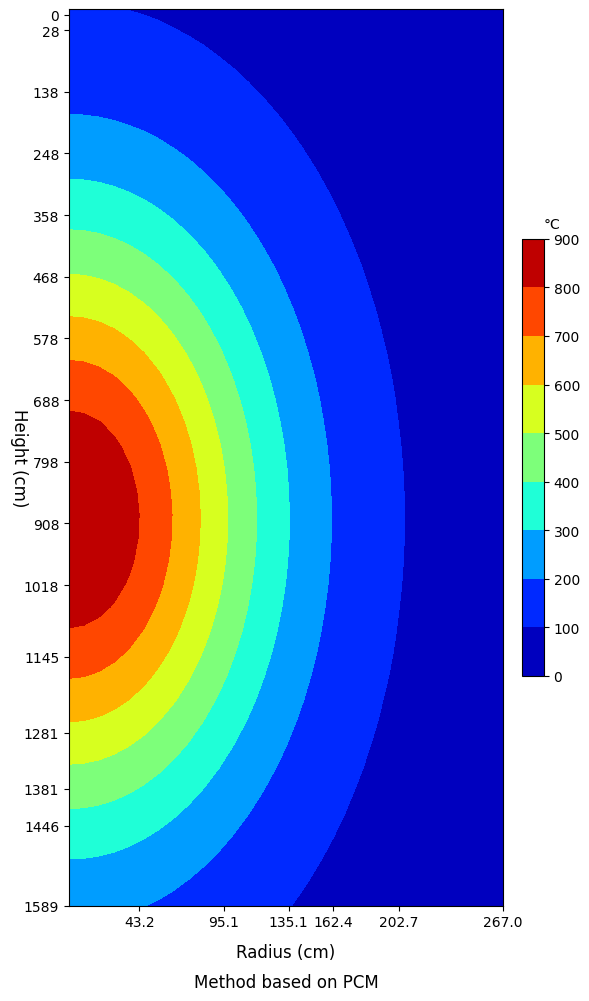

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class HTRPM_ThermalHydraulics:
    def __init__(self, num_nodes, num_edges):
        self.N = num_nodes   # Jumlah nodes
        self.J = num_edges   # Jumlah edges

        # Konstanta Gas Helium
        self.R = 2077.1      # Helium J/(kg.K)
        self.s = 1.0         # Faktor kompresibilitas
        self.g = 9.81        # Gravitasi
        self.dt = 0.1        # Tim
        self.alpha = 0.5     # Faktor relaksasi

        # Fluida
        self.p0 = np.ones(self.N) * 101325  # Tekanan stagnasi (Asumsi awal 1 atm)
        self.p = np.ones(self.N) * 101325   # Tekanan statis
        self.rho = np.ones(self.N) * 1.2    # Massa jenis
        self.T = np.ones(self.N) * 300      # Suhu fluida
        self.h0 = np.zeros(self.N)
        self.V_vol = np.ones(self.N)        # Volume simpul (V_i)
        self.d = np.zeros(self.N)
        self.Q = np.zeros(self.J)
        self.V = np.zeros(self.J)
        self.A = np.ones(self.J)
        self.dx = np.ones(self.J)
        self.dz = np.zeros(self.J)
        self.D = np.ones(self.J)
        self.f_tilde = np.zeros(self.J)

        # Padat
        self.T_solid = np.ones(self.N) * 300
        self.m_solid = np.ones(self.N)
        self.Cp_solid = np.ones(self.N)
        self.qn = np.zeros(self.N)

    def equation_of_state(self):
        # Persamaan keadaan gas Helium
        for i in range(self.N):
            if self.T[i] > 0:
                self.rho[i] = self.p[i] / (self.s * self.R * self.T[i])

    def solve_solid_energy(self):
        # Persamaan energi benda padat diskrit
        for i in range(self.N):
            total_heat = self.qn[i]
            dT_dt = total_heat / (self.m_solid[i] * self.Cp_solid[i])
            self.T_solid[i] += dT_dt * self.dt

    def simple_algorithm_step(self):
        p0_bar = np.copy(self.p0)
        rho_bar = np.copy(self.rho)
        C_matrix = np.eye(self.N)
        b_vector = np.zeros(self.N)

        for i in range(self.N):
            b_vector[i] = (self.V_vol[i] * (rho_bar[i] - self.rho[i]) / self.dt)
        p0_prime = np.linalg.solve(C_matrix, b_vector)

        for i in range(self.N):
            self.p0[i] = p0_bar[i] + p0_prime[i]

        self.solve_solid_energy()

    def run_simulation(self, total_time):
        steps = int(total_time / self.dt)
        for t in range(steps):
            self.equation_of_state()
            self.simple_algorithm_step()

    def plot_2d_results(self):
        # Grid
        r_vals = np.linspace(0, 267, 30)
        z_vals = np.linspace(-10, 1589.2, 40)
        R, Z = np.meshgrid(r_vals, z_vals)
        T_plot = np.zeros_like(R) + 50
        core_z_center = 900
        core_r_center = 0
        T_plot += 850 * np.exp(-(((Z - core_z_center)**2 / 300000) + ((R - core_r_center)**2 / 15000)))
        T_plot = np.clip(T_plot, 0, 900)
        U_plot = np.zeros_like(R)
        V_plot = np.zeros_like(R)
        V_plot[(R < 135) & (Z > 0) & (Z < 1200)] = 80
        V_plot[(R > 180) & (R < 220) & (Z > -100) & (Z < 1500)] = -100
        U_plot[(Z > 1100) & (Z < 1300) & (R > 50) & (R < 200)] = 60

        fig, ax = plt.subplots(figsize=(6, 10))
        levels = np.linspace(0, 900, 10)
        contour = ax.contourf(R, Z, T_plot, levels=levels, cmap='jet')

        ax.set_xlim(0, 267)
        ax.set_ylim(-10, 1589.2)
        ax.invert_yaxis()
        ax.set_xlabel('Radius (cm)', fontsize=12, labelpad=10)
        ax.set_ylabel('Height (cm)', fontsize=12, labelpad=10, rotation=270, va='bottom')
        ax.set_title('Method based on PCM', fontsize=12, y=-0.1)

        ax.set_xticks([43.2, 95.1, 135.1, 162.4, 202.7, 267])
        ax.set_yticks([0, 27.5, 137.5, 247.5, 357.5, 467.5,
                       577.5, 687.5, 797.5, 907.5, 1017.5, 1145.4, 1280.8,
                       1380.8, 1446.3, 1589.2])
        cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('°C', rotation=0, labelpad=-20, y=1.05)
        cbar.set_ticks(np.arange(0, 1000, 100))
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    reaktor_htrpm = HTRPM_ThermalHydraulics(num_nodes=100, num_edges=150)
    reaktor_htrpm.run_simulation(total_time=3.0)
    reaktor_htrpm.plot_2d_results()